# Task 5: Personal Loan Acceptance Prediction

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


## Loading Dataset

In [2]:
df = pd.read_csv("bank.csv")

print("Dataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape:
(11162, 17)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')

First 5 Rows:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1    

## Dataset Information

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB
None


## Checking Missing Values

In [4]:
print(df.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


## Age Distribution

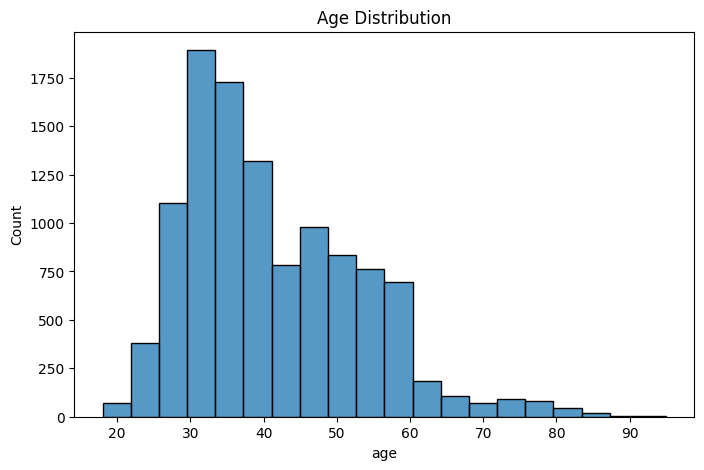

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=20)

plt.title("Age Distribution")

plt.show()

### Observation

The age distribution shows that most customers are between 30 and 50 years old.

## Job Analysis

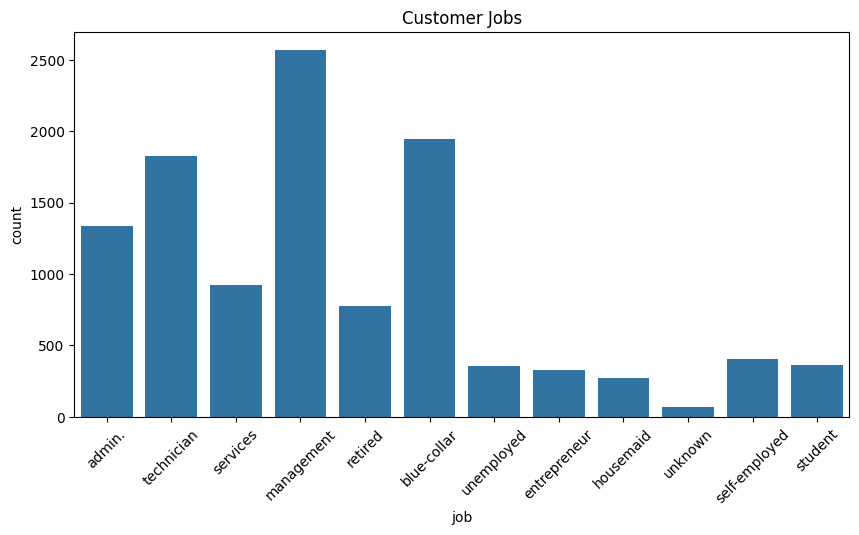

In [6]:
plt.figure(figsize=(10,5))

sns.countplot(x="job", data=df)

plt.xticks(rotation=45)

plt.title("Customer Jobs")

plt.show()

### Observation

Management, blue-collar, and technician are among the most common job categories.

## Marital Status Analysis

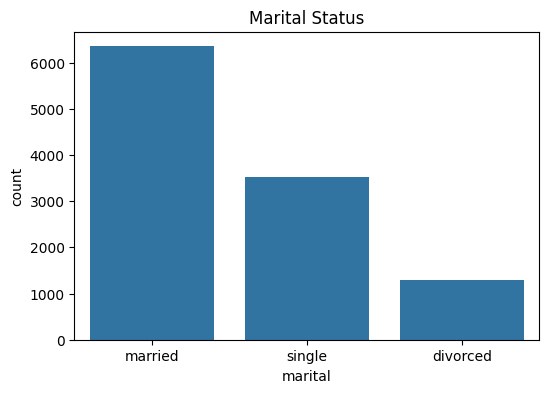

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="marital", data=df)

plt.title("Marital Status")

plt.show()

### Observation

Most customers are married, followed by single and divorced customers.

## Data Preprocessing

In [10]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)

(11162, 43)


## Feature Selection

In [11]:
X = df_encoded.drop("deposit_yes", axis=1)

y = df_encoded["deposit_yes"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (11162, 42)
Target Shape: (11162,)


## Splitting Data

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8929, 42)
Testing Data: (2233, 42)


## Logistic Regression Model

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=10000,
    solver="liblinear"
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


## Model Evaluation

In [16]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8078817733990148


## Business Insights

### Observation 1
Most customers are between 30 and 50 years old.

### Observation 2
Management, technician, and blue-collar jobs are among the most common customer groups.

### Observation 3
Married customers form the largest customer segment.

### Observation 4
The Logistic Regression model achieved an accuracy of 80.79%, indicating good predictive performance.

### Observation 5
Customer demographics and banking history can help predict whether a customer is likely to accept a personal loan offer.

## Conclusion

In this project, a Logistic Regression model was developed to predict whether a customer would accept a personal loan offer.

The dataset was explored using age, job, and marital status information. Data preprocessing and encoding techniques were applied before model training.

The model achieved an accuracy of 80.79%, demonstrating that customer characteristics can be effectively used to predict loan acceptance.

Such predictions can help banks target the right customers and improve marketing campaign performance.